In [3]:

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler


data = pd.read_csv("data.csv", encoding="latin1")


no2_values = data["no2"].dropna().to_numpy()


roll_number = 102303563

a_r = 0.5 * (roll_number % 7)
b_r = 0.3 * ((roll_number % 5) + 1)

print("a_r =", a_r)
print("b_r =", b_r)


z_values = no2_values + a_r * np.sin(b_r * no2_values)


scaler = StandardScaler()
z_scaled = scaler.fit_transform(z_values.reshape(-1, 1))

print("Transformed dataset shape:", z_scaled.shape)

a_r = 2.5
b_r = 1.2
Transformed dataset shape: (419509, 1)


/tmp/ipython-input-2961741675.py:6: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("data.csv", encoding="latin1")


In [4]:


import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class GenNet(nn.Module):
    def __init__(self):
        super(GenNet, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(1, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, noise_vector):
        return self.network(noise_vector)



class DiscNet(nn.Module):
    def __init__(self):
        super(DiscNet, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(1, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, sample):
        return self.network(sample)


generator = GenNet().to(device)
discriminator = DiscNet().to(device)

print("GAN architecture created successfully.")

GAN architecture created successfully.


In [5]:

import torch.optim as optim

real_data = torch.tensor(z_scaled, dtype=torch.float32).to(device)

loss_function = nn.BCELoss()

g_optimizer = optim.Adam(generator.parameters(), lr=0.0008, betas=(0.5, 0.999))
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0008, betas=(0.5, 0.999))

epochs = 2500
batch_size = 128

for epoch in range(epochs):

    indices = np.random.randint(0, real_data.size(0), batch_size)
    real_batch = real_data[indices]


    noise = torch.randn(batch_size, 1).to(device)
    fake_batch = generator(noise)


    discriminator.zero_grad()

    real_labels = torch.ones(batch_size, 1).to(device)
    fake_labels = torch.zeros(batch_size, 1).to(device)

    real_loss = loss_function(discriminator(real_batch), real_labels)
    fake_loss = loss_function(discriminator(fake_batch.detach()), fake_labels)

    d_total_loss = real_loss + fake_loss
    d_total_loss.backward()
    d_optimizer.step()


    generator.zero_grad()

    predicted = discriminator(fake_batch)
    g_loss = loss_function(predicted, real_labels)

    g_loss.backward()
    g_optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | D Loss: {d_total_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

print("Training finished.")

Epoch 0 | D Loss: 1.4239 | G Loss: 0.7971
Epoch 500 | D Loss: 1.3846 | G Loss: 0.7163
Epoch 1000 | D Loss: 1.3861 | G Loss: 0.7023
Epoch 1500 | D Loss: 1.3821 | G Loss: 0.6708
Epoch 2000 | D Loss: 1.3833 | G Loss: 0.6855
Training finished.


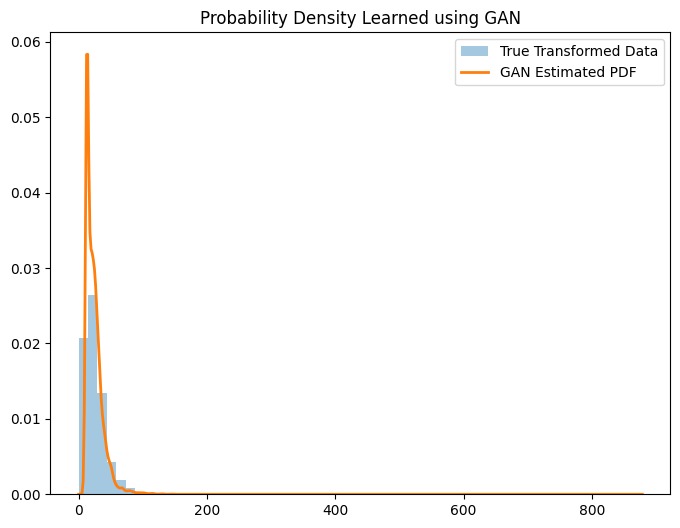

In [6]:

import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


noise_test = torch.randn(15000, 1).to(device)
generated_samples = generator(noise_test).detach().cpu().numpy()


generated_samples = scaler.inverse_transform(generated_samples)

kde_estimator = gaussian_kde(generated_samples.flatten())

z_axis = np.linspace(min(z_values), max(z_values), 500)
estimated_pdf = kde_estimator(z_axis)


plt.figure(figsize=(8, 6))
plt.hist(z_values, bins=60, density=True, alpha=0.4, label="True Transformed Data")
plt.plot(z_axis, estimated_pdf, linewidth=2, label="GAN Estimated PDF")
plt.title("Probability Density Learned using GAN")
plt.legend()
plt.show()